# Прогноз оттока клиентов (Customer Churn Prediction)

Ноутбук решает задачу бинарной классификации: предсказать, уйдёт ли клиент телеком-компании (`Churn`).

**План работы:**
1. Импорт библиотек и загрузка данных
2. Первичный обзор данных
3. Предобработка данных
4. Разведочный анализ (EDA)
5. Feature Engineering
6. Кодирование категориальных признаков
7. Обучение моделей и сравнение по метрикам (ROC-AUC, Recall, Confusion Matrix)


## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Загрузка данных

In [2]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape


(7043, 21)

Посмотрим на первые строки таблицы, чтобы понять состав признаков.

In [3]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Общая информация о типах данных и количестве непустых значений.

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Статистики по числовым признакам.

In [5]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Статистики по категориальным (текстовым) признакам.

In [6]:
df.describe(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## 3. Проверка пропусков

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Целевая переменная: Churn
Посчитаем, сколько клиентов ушло, а сколько осталось — в абсолютных числах и в процентах.

In [8]:
churn_counts = df['Churn'].value_counts()
churn_percents = df['Churn'].value_counts(normalize=True) * 100

In [9]:
print(churn_counts)
print("\nВ процентах:")
print(churn_percents.round(1))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

В процентах:
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


`TotalCharges` формально имеет тип `object` — проверим, есть ли в столбце пустые строки (они обычно скрывают пропуски, которые `isnull()` выше не заметил).

In [10]:
(df['TotalCharges'] == ' ').sum()


np.int64(11)

## 4. Визуализация: доля оттока
Круговая диаграмма наглядно показывает дисбаланс классов.

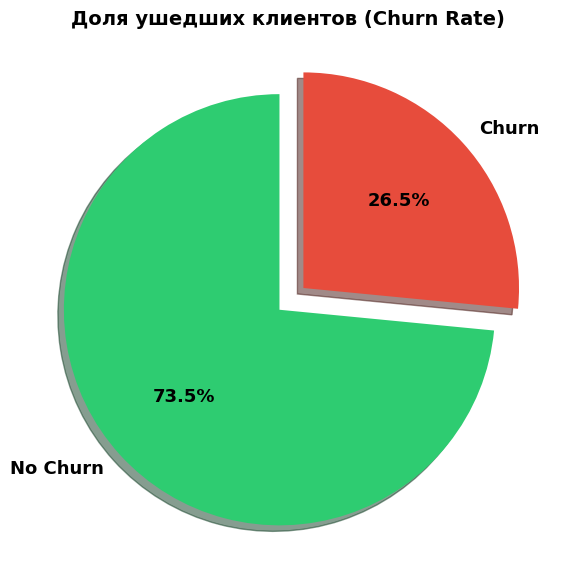

In [11]:
plt.figure(figsize=(7, 7))
plt.pie(churn_counts, 
        labels=['No Churn', 'Churn'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        explode=(0.05, 0.1),
        shadow=True,
        startangle=90,
        textprops={'fontsize': 13, 'fontweight': 'bold'})
plt.title('Доля ушедших клиентов (Churn Rate)', fontsize=14, fontweight='bold')
plt.show()

## 5. Предобработка данных
- удаляем `customerID` — это идентификатор, а не признак;
- приводим `TotalCharges` к числовому типу;
- убираем клиентов с `tenure == 0` (у них ещё не было счетов, отсюда и пропуски в `TotalCharges`);
- на всякий случай подстраховываемся `fillna(0)`.

In [12]:
df = df.drop('customerID', axis=1)


In [13]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'Churn']]


,tenure,MonthlyCharges,Churn
488,0,52.55,No
753,0,20.25,No
936,0,80.85,No
1082,0,25.75,No
1340,0,56.05,No
3331,0,19.85,No
3826,0,25.35,No
4380,0,20.00,No
5218,0,19.70,No
6670,0,73.35,No


In [14]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

In [15]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)


Проверим результат предобработки.

In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 6. Разведочный анализ (EDA)
### 6.1 Churn rate по категориальным признакам
Для каждого категориального признака (и `SeniorCitizen`) посмотрим долю оттока внутри каждой категории. Это помогает найти сегменты клиентов с повышенным риском ухода.

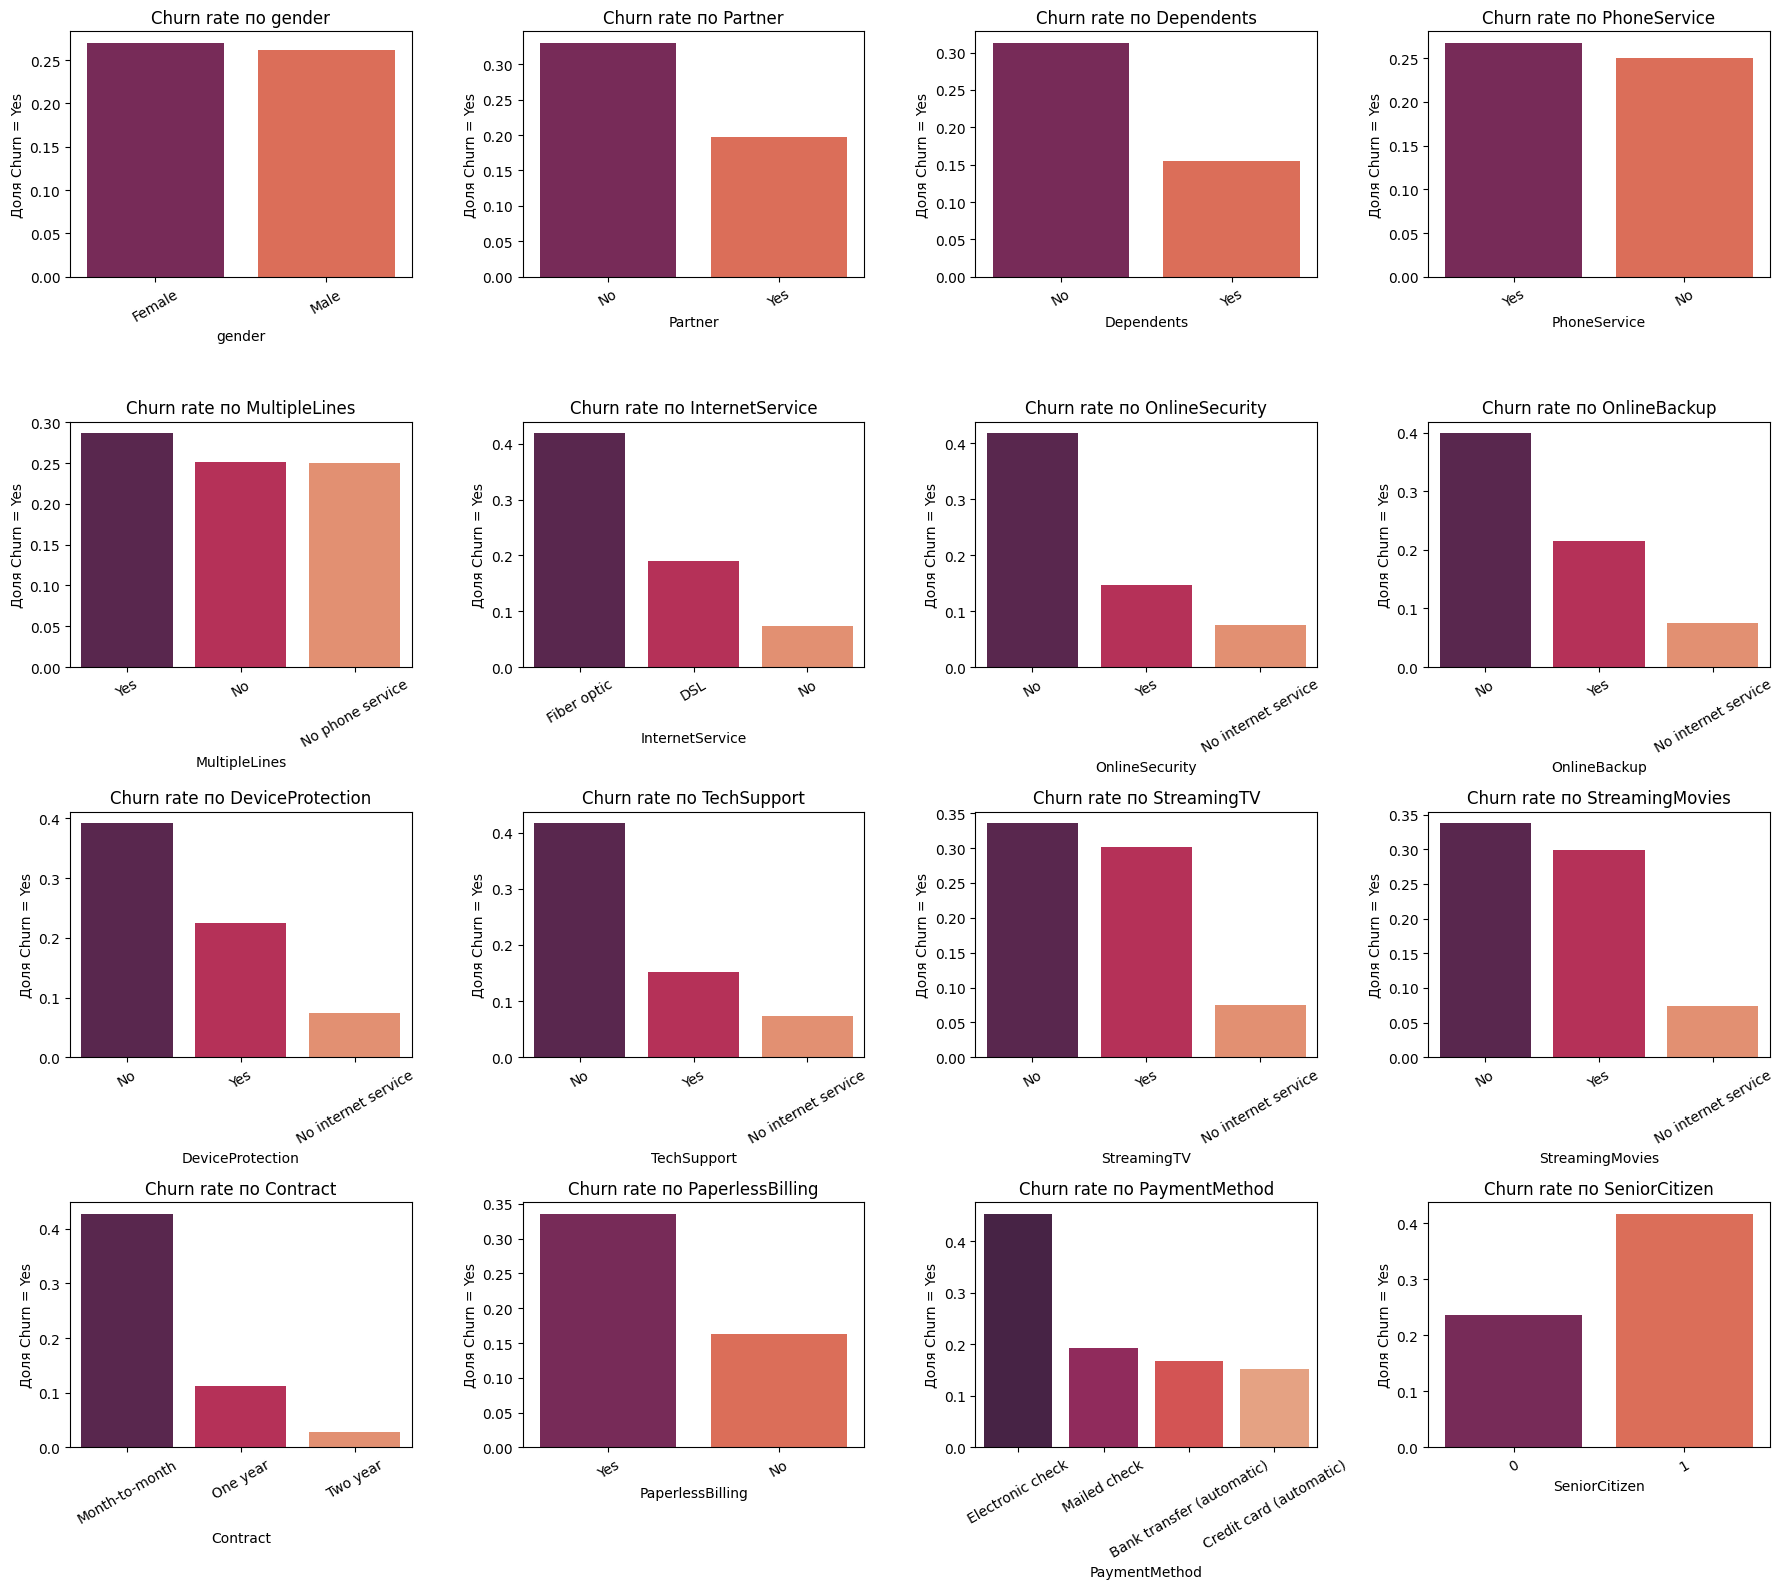

In [17]:
cat_cols_to_check = [c for c in df.select_dtypes(include='object').columns if c != 'Churn']
cat_cols_to_check += ['SeniorCitizen']

n_cols = 4
n_rows = -(-len(cat_cols_to_check) // n_cols)  
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols_to_check):
    rates = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()['Yes']
    rates = rates.sort_values(ascending=False)
    sns.barplot(x=rates.index, y=rates.values, ax=ax, hue=rates.index, palette='rocket', legend=False)
    ax.set_title(f'Churn rate по {col}')
    ax.set_ylabel('Доля Churn = Yes')
    ax.tick_params(axis='x', rotation=30)

for ax in axes[len(cat_cols_to_check):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


### 6.2 Новые агрегаты для анализа
Прежде чем перейти к моделированию, создадим пару вспомогательных признаков и посмотрим на связи в данных:
- `num_services` — сколько доп. услуг подключено;
- `has_family` — есть партнёр или иждивенцы.

In [18]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

In [19]:
df['has_family'] = ((df['Partner']=='Yes') | (df['Dependents']=='Yes')).astype(int)

Матрица оттока по типу контракта и способу оплаты — ищем «опасные» комбинации.

In [20]:
pd.crosstab(df['Contract'], df['PaymentMethod'], values=df['Churn']=='Yes', aggfunc='mean')

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,0.341256,0.327808,0.537297,0.315789
One year,0.097187,0.103015,0.184438,0.068452
Two year,0.033808,0.022414,0.077381,0.008000


In [21]:
df['high_risk_combo'] = ((df['Contract']=='Month-to-month') & (df['PaymentMethod']=='Electronic check')).astype(int)

Средний ежемесячный платёж по типу интернет-услуги.

In [22]:
df.groupby('InternetService')['MonthlyCharges'].mean()

InternetService
DSL            58.088017
Fiber optic    91.500129
No             21.076283
Name: MonthlyCharges, dtype: float64

### 6.3 Распределения числовых признаков
Гистограммы `tenure`, `MonthlyCharges`, `TotalCharges` в разрезе Churn.

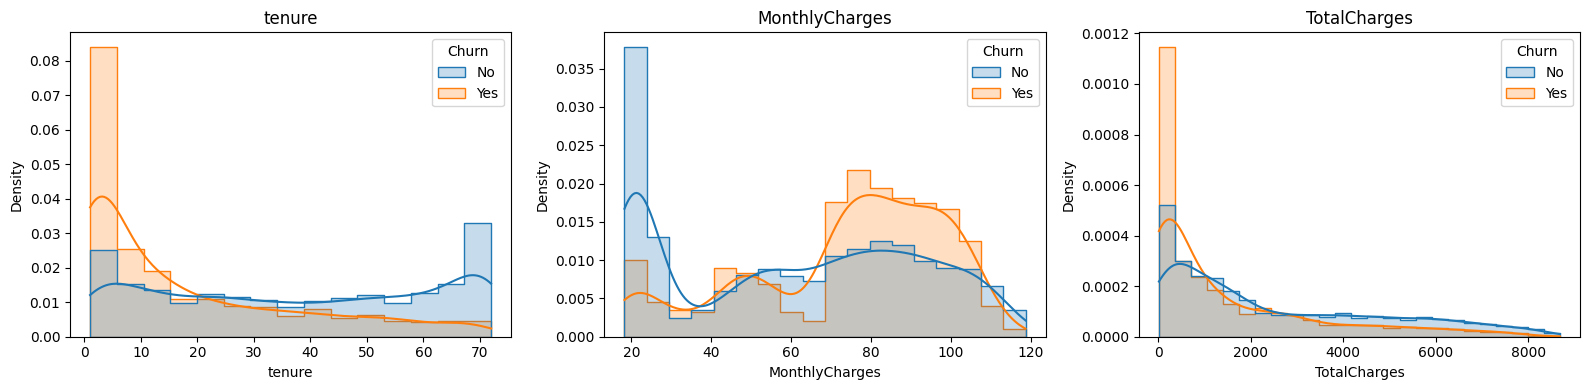

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax, element='step', stat='density', common_norm=False)
    ax.set_title(col)

plt.tight_layout()
plt.show()


Boxplot тех же признаков — удобно сравнивать медианы и разброс между группами.

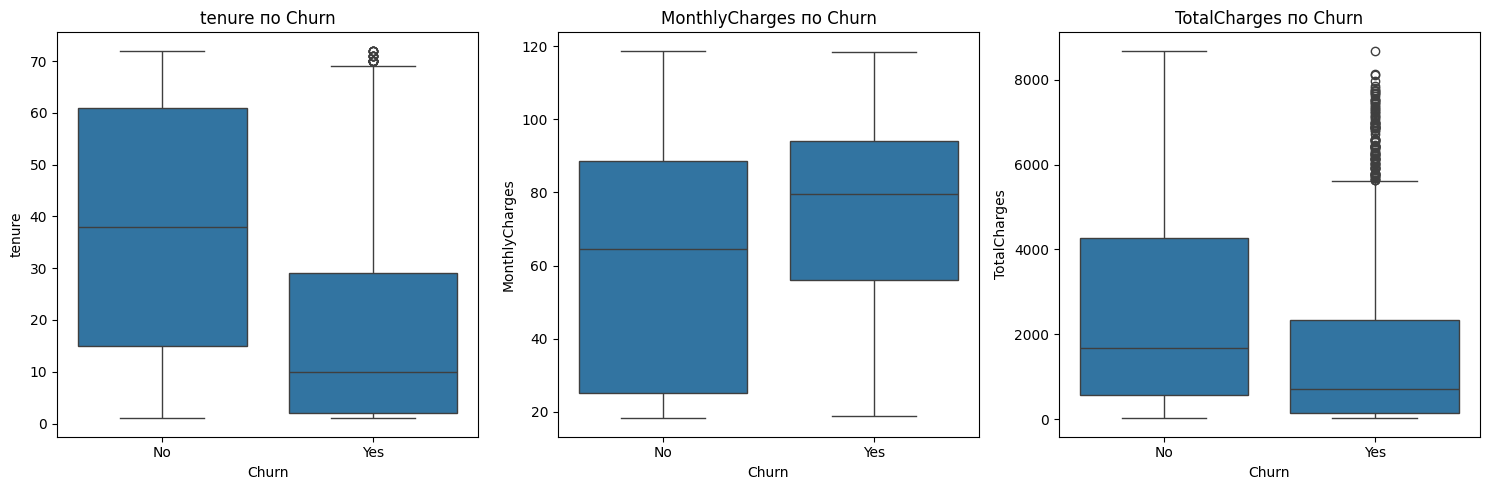

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax)
    ax.set_title(f'{col} по Churn')
plt.tight_layout()
plt.show()

## 7. Feature Engineering
Добавляем производные признаки, которые могут усилить сигнал для модели:
- `tenure_group` / `is_new_customer` — группировка по стажу;
- `charges_group` — группировка по уровню платежа;
- `charges_diff` — расхождение между "ожидаемой" суммой (`tenure * MonthlyCharges`) и фактической `TotalCharges`.

In [25]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-12', '13-24', '25-48', '49-60', '61-72'],
    include_lowest=True
)

df['is_new_customer'] = (df['tenure'] < 12).astype(int)

In [26]:
df['charges_group'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 70, 120],
    labels=['low', 'mid', 'high'],
    include_lowest=True
)

In [27]:
df['charges_diff'] = (df['tenure'] * df['MonthlyCharges']) - df['TotalCharges']

Проверим таблицу с новыми признаками.

In [28]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,num_services,has_family,high_risk_combo,tenure_group,is_new_customer,charges_group,charges_diff
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,29.85,29.85,No,1,1,1,0-12,1,low,0.00
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,56.95,1889.50,No,2,0,0,25-48,0,mid,46.80
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,53.85,108.15,Yes,2,0,0,0-12,1,mid,-0.45
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,42.30,1840.75,No,3,0,0,25-48,0,mid,62.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,70.70,151.65,Yes,0,0,1,0-12,1,high,-10.25
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,...,99.65,820.50,Yes,3,0,1,0-12,1,high,-23.30
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,...,89.10,1949.40,No,2,1,0,13-24,0,high,10.80
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,...,29.75,301.90,No,1,0,0,0-12,1,low,-4.40
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,...,104.80,3046.05,Yes,4,1,1,25-48,0,high,-111.65
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,...,56.15,3487.95,No,2,1,0,61-72,0,mid,-6.65


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7032 non-null   object  
 1   SeniorCitizen     7032 non-null   int64   
 2   Partner           7032 non-null   object  
 3   Dependents        7032 non-null   object  
 4   tenure            7032 non-null   int64   
 5   PhoneService      7032 non-null   object  
 6   MultipleLines     7032 non-null   object  
 7   InternetService   7032 non-null   object  
 8   OnlineSecurity    7032 non-null   object  
 9   OnlineBackup      7032 non-null   object  
 10  DeviceProtection  7032 non-null   object  
 11  TechSupport       7032 non-null   object  
 12  StreamingTV       7032 non-null   object  
 13  StreamingMovies   7032 non-null   object  
 14  Contract          7032 non-null   object  
 15  PaperlessBilling  7032 non-null   object  
 16  PaymentMethod     7032 non-nu

## 8. Кодирование категориальных признаков
### 8.1 Бинарные признаки (Yes/No, Male/Female) → 0/1

In [30]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})


In [31]:
for col in binary_cols + ['gender']:
    print(f"{col}: {df[col].unique()}")


Partner: [1 0]
Dependents: [0 1]
PhoneService: [0 1]
PaperlessBilling: [1 0]
Churn: [0 1]
gender: [0 1]


Проверим, какие признаки ещё остались нечисловыми и сколько в них уникальных категорий.

In [32]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} уникальных -> {df[col].unique()}")


MultipleLines: 3 уникальных -> ['No phone service' 'No' 'Yes']
InternetService: 3 уникальных -> ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 3 уникальных -> ['No' 'Yes' 'No internet service']
OnlineBackup: 3 уникальных -> ['Yes' 'No' 'No internet service']
DeviceProtection: 3 уникальных -> ['No' 'Yes' 'No internet service']
TechSupport: 3 уникальных -> ['No' 'Yes' 'No internet service']
StreamingTV: 3 уникальных -> ['No' 'Yes' 'No internet service']
StreamingMovies: 3 уникальных -> ['No' 'Yes' 'No internet service']
Contract: 3 уникальных -> ['Month-to-month' 'One year' 'Two year']
PaymentMethod: 4 уникальных -> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


### 8.2 One-Hot Encoding для многоклассовых категориальных признаков

In [33]:
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                   'OnlineBackup', 'DeviceProtection', 'TechSupport',
                   'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod',
                   'tenure_group', 'charges_group'] 

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
dummy_cols = [c for c in df.columns if df[c].dtype == 'bool']
df[dummy_cols] = df[dummy_cols].astype(int)


## 9. Финальная проверка данных перед моделированием

In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  num_services                           7032 non-null   int64  
 11  has_famil

In [35]:
df['Churn'].value_counts(normalize=True)


Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [36]:
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()


tenure                                                     \
        count       mean        std  min   25%   50%   75%   max   
Churn                                                              
0      5163.0  37.650010  24.076940  1.0  15.0  38.0  61.0  72.0   
1      1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      MonthlyCharges             ...                 TotalCharges  \
               count       mean  ...     75%     max        count   
Churn                            ...                                
0             5163.0  61.307408  ...  88.475  118.75       5163.0   
1             1869.0  74.441332  ...  94.200  118.35       1869.0   

                                                                             
              mean          std    min      25%      50%       75%      max  
Churn                                                                        
0      2555.344141  2329.456984  18.80  577.825  1683.60  4264.125  8672.45  
1      1531.796094  1890.822994  18.85  134.500   703.55  2331.300  8684.80  

[2 rows x 24 columns]

Корреляция между ключевыми числовыми признаками.

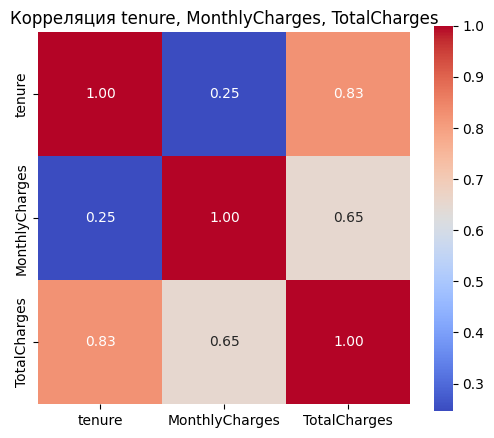

In [37]:
core_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(6, 5))
sns.heatmap(df[core_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляция tenure, MonthlyCharges, TotalCharges')
plt.show()


Финальный взгляд на датасет перед разбиением на train/test.

In [38]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24,tenure_group_25-48,tenure_group_49-60,tenure_group_61-72,charges_group_mid,charges_group_high
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,1,0,0,0,0,0,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,1,0,1,0,0,1,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,1,0,0,0,0,1,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,0,0,0,0,1,0,0,1,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,1,0,0,0,0,0,0,1
5,0,0,0,0,8,1,1,99.65,820.50,1,...,0,0,1,0,0,0,0,0,0,1
6,1,0,0,1,22,1,1,89.10,1949.40,0,...,0,1,0,0,1,0,0,0,0,1
7,0,0,0,0,10,0,0,29.75,301.90,0,...,0,0,0,1,0,0,0,0,0,0
8,0,0,1,0,28,1,1,104.80,3046.05,1,...,0,0,1,0,0,1,0,0,0,1
9,1,0,0,1,62,1,0,56.15,3487.95,0,...,0,0,0,0,0,0,0,1,1,0


## 10. Разделение на train/test
Используем стратификацию по `Churn`, чтобы сохранить пропорцию классов в обеих выборках.

In [39]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Вспомогательная функция для оценки моделей
Чтобы не дублировать код, напишем функцию, которая для любой модели строит **Confusion Matrix** и печатает значение **Recall** — метрики, критичной для задачи оттока (важно не пропустить клиентов, которые действительно уйдут).

In [40]:
from sklearn.metrics import confusion_matrix, recall_score

def show_confusion_matrix(y_true, y_pred, model_name='Model'):
    """Строит confusion matrix и печатает recall для заданной модели."""
    cm = confusion_matrix(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.show()

    print(f'Recall ({model_name}): {recall:.4f}')
    return cm, recall


## 11. Baseline-модель: LogisticRegression
Простая логистическая регрессия со стандартизацией признаков внутри `Pipeline` и `class_weight='balanced'` для компенсации дисбаланса классов.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

### Оценка на тестовой выборке: classification report и ROC-AUC

In [42]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407

ROC-AUC: 0.8337936336199532


### Confusion Matrix и Recall для baseline-модели

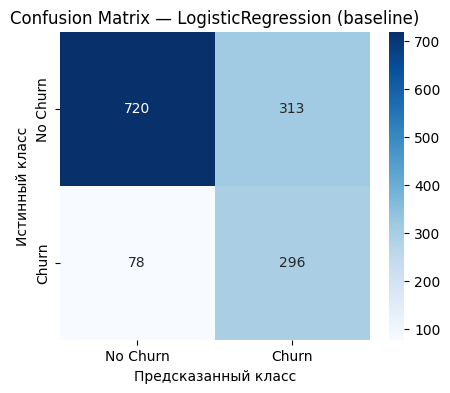

Recall (LogisticRegression (baseline)): 0.7914


(array([[720, 313],
        [ 78, 296]]),
 0.7914438502673797)

In [43]:
show_confusion_matrix(y_test, y_pred, 'LogisticRegression (baseline)')


## Baseline: DummyClassifier (для честного сравнения)

In [44]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print('Dummy ROC-AUC:', roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]))
print(classification_report(y_test, dummy.predict(X_test)))


Dummy ROC-AUC: 0.5
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1033
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Confusion Matrix и Recall для DummyClassifier
Это нижняя граница качества — модель, которая всегда предсказывает самый частый класс.

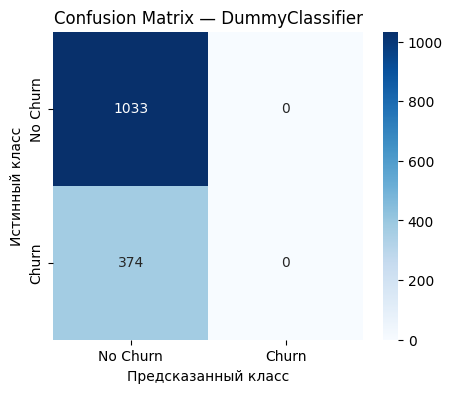

Recall (DummyClassifier): 0.0000


(array([[1033,    0],
        [ 374,    0]]),
 0.0)

In [45]:
show_confusion_matrix(y_test, dummy.predict(X_test), 'DummyClassifier')


## Кросс-валидация
Один train/test split даёт неустойчивую оценку метрики (сильно зависит от random_state).
Ниже — StratifiedKFold + cross_validate по нескольким метрикам сразу, на ПОЛНОМ X (без утечки:
CV сам разбивает данные на фолды и правильно фитит препроцессинг внутри Pipeline).

In [46]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ВАЖНО: скейлер должен быть внутри Pipeline, а не применён заранее ко всему X,
# иначе на каждом фолде CV будет утечка информации о test-части фолда в train-часть.
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

scoring = ['roc_auc', 'f1', 'precision', 'recall']
cv_results = cross_validate(logreg_pipe, X, y, cv=cv, scoring=scoring)

for m in scoring:
    scores = cv_results[f'test_{m}']
    print(f'{m}: {scores.mean():.4f} +/- {scores.std():.4f}')


roc_auc: 0.8448 +/- 0.0030
f1: 0.6245 +/- 0.0101
precision: 0.5129 +/- 0.0114
recall: 0.7983 +/- 0.0123


## Подбор гиперпараметров: LogisticRegression

In [47]:
from sklearn.model_selection import GridSearchCV

param_grid_logreg = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear']
}

grid_logreg = GridSearchCV(
    logreg_pipe, param_grid_logreg, scoring='roc_auc', cv=cv, n_jobs=-1
)
grid_logreg.fit(X_train, y_train)

print('Лучшие параметры:', grid_logreg.best_params_)
print('Лучший CV ROC-AUC:', grid_logreg.best_score_)

best_logreg = grid_logreg.best_estimator_
y_proba = best_logreg.predict_proba(X_test)[:, 1]
print('Test ROC-AUC:', roc_auc_score(y_test, y_proba))


Лучшие параметры: {'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Лучший CV ROC-AUC: 0.8462623596006058
Test ROC-AUC: 0.8331698339812911


### Confusion Matrix и Recall для лучшей LogisticRegression (после подбора гиперпараметров)

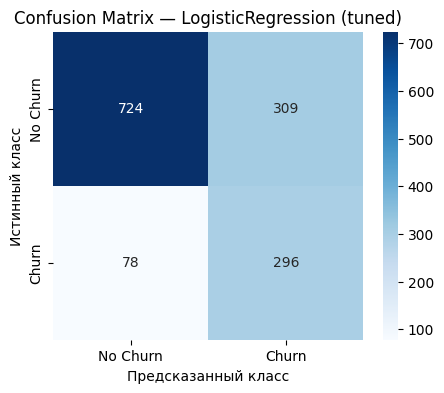

Recall (LogisticRegression (tuned)): 0.7914


(array([[724, 309],
        [ 78, 296]]),
 0.7914438502673797)

In [48]:
show_confusion_matrix(y_test, best_logreg.predict(X_test), 'LogisticRegression (tuned)')


## 12. CatBoost
Градиентный бустинг с автоматическим взвешиванием классов (`scale_pos_weight`) и подбором гиперпараметров через `RandomizedSearchCV`.

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

class_counts = y_train.value_counts()
neg, pos = class_counts.loc[0], class_counts.loc[1]
spw = float(neg / pos)

cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0,
    scale_pos_weight=spw
)

param_dist_cat = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'iterations': [200, 400, 600],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

search_cat = RandomizedSearchCV(
    cat_model, param_dist_cat, n_iter=20, scoring='roc_auc',
    cv=cv, random_state=42, n_jobs=-1
)
search_cat.fit(X_train, y_train)

print('Лучшие параметры CatBoost:', search_cat.best_params_)
print('Лучший CV ROC-AUC:', search_cat.best_score_)

best_cat = search_cat.best_estimator_
y_proba_cat = best_cat.predict_proba(X_test)[:, 1]
print('Test ROC-AUC:', roc_auc_score(y_test, y_proba_cat))
print(classification_report(y_test, best_cat.predict(X_test)))


### Confusion Matrix и Recall для CatBoost

In [ ]:
show_confusion_matrix(y_test, best_cat.predict(X_test), 'CatBoost')


## 13. LightGBM
Ещё один градиентный бустинг для сравнения.

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(random_state=42, scale_pos_weight=spw, verbose=-1)

param_dist_lgbm = {
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [200, 400, 600],
    'min_child_samples': [10, 20, 30]
}

search_lgbm = RandomizedSearchCV(
    lgbm_model, param_dist_lgbm, n_iter=20, scoring='roc_auc',
    cv=cv, random_state=42, n_jobs=-1
)
search_lgbm.fit(X_train, y_train)

print('Лучшие параметры LightGBM:', search_lgbm.best_params_)
print('Лучший CV ROC-AUC:', search_lgbm.best_score_)

best_lgbm = search_lgbm.best_estimator_
y_proba_lgbm = best_lgbm.predict_proba(X_test)[:, 1]
print('Test ROC-AUC:', roc_auc_score(y_test, y_proba_lgbm))
print(classification_report(y_test, best_lgbm.predict(X_test)))


### Confusion Matrix и Recall для LightGBM

In [ ]:
show_confusion_matrix(y_test, best_lgbm.predict(X_test), 'LightGBM')


## Сравнение моделей

Сводная таблица ROC-AUC по всем моделям, отсортированная по убыванию качества.

In [ ]:
results = pd.DataFrame({
    'model': ['Dummy', 'LogisticRegression', 'CatBoost', 'LightGBM'],
    'test_roc_auc': [
        roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, best_logreg.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, best_cat.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, best_lgbm.predict_proba(X_test)[:, 1]),
    ]
}).sort_values('test_roc_auc', ascending=False)

results


### Сводная таблица Recall по всем моделям
Дополнительно соберём recall всех моделей в одну таблицу — это удобно для быстрого сравнения.

In [ ]:
recall_summary = pd.DataFrame({
    'model': ['Dummy', 'LogisticRegression', 'CatBoost', 'LightGBM'],
    'test_recall': [
        recall_score(y_test, dummy.predict(X_test)),
        recall_score(y_test, best_logreg.predict(X_test)),
        recall_score(y_test, best_cat.predict(X_test)),
        recall_score(y_test, best_lgbm.predict(X_test)),
    ]
}).sort_values('test_recall', ascending=False)

recall_summary


## Важность признаков (лучшая модель по ROC-AUC)

In [ ]:
best_model_name = results.iloc[0]['model']
model_map = {'CatBoost': best_cat, 'LightGBM': best_lgbm, 'LogisticRegression': best_logreg}

if best_model_name in ('CatBoost', 'LightGBM'):
    fi = pd.Series(model_map[best_model_name].feature_importances_, index=X.columns)
    fi.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8, 6))
    plt.title(f'Топ-15 важных признаков ({best_model_name})')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print('Лучшая модель — линейная, смотрите коэффициенты через .coef_')
